In [1]:
from datasets import load_dataset
from tqdm.auto import tqdm
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import AutoModelForSequenceClassification
from transformers import pipeline
import copy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from rich import print
import numpy as np
import pandas as pd
import random
from sklearn.neighbors import KNeighborsClassifier
import pickle
from random import randint

/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [2]:
ds = load_dataset("jondurbin/gutenberg-dpo-v0.1")['train']

In [3]:
ds

Dataset({
    features: ['id', 'source', 'chosen', 'rejected', 'prompt', 'rejected_model'],
    num_rows: 918
})

In [4]:
prompts = []
chosen_rejected = []
novel = []

for t in ['chosen', 'rejected']:
    for i in tqdm(range(len(ds))):
        # prompts.append((ds[i]['prompt'] + '\n' + ds[i][t])[:5000])
        prompts.append((ds[i][t])[:5000])
        chosen_rejected.append(t)
        novel.append(ds[i]['source'])

chosen_rejected = np.array(chosen_rejected)
novel = np.array(novel)

100%|██████████| 918/918 [00:00<00:00, 13862.12it/s]


# Model

In [5]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '2,3'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

2

In [6]:
# tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models')
# model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-14B-Instruct", cache_dir='/data/takis/models')
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-14B-Instruct", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)

model = model.eval()

Loading checkpoint shards: 100%|██████████| 8/8 [00:00<00:00,  8.15it/s]


## Hidden states

In [7]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if (name in activations):
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook


for i, layer in enumerate(model.model.layers):
    layer.self_attn.register_forward_hook(get_activation(i))

In [8]:
hidden_states = []

pbar = tqdm(enumerate(prompts), total=len(prompts))
for i, p in pbar:

    pbar.set_description('cur prompt length (chars): %d' %(len(p)))
    
    with torch.no_grad():
        inputs = tokenizer(p, return_tensors="pt").input_ids
        outputs = model.forward(inputs.to(device))
        
    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
        activations[k] =  torch.mean(activations[k], dim=-2)


    hidden_states.append(copy.deepcopy(activations))
    activations = {}

cur prompt length (chars): 3319: 100%|██████████| 1836/1836 [08:11<00:00,  3.74it/s]


## Prototypes

In [9]:
target_layers = [i for i in range(len(model.model.layers))]

# all_prompts_prototypes = [{target_layer: torch.mean(hidden_states[i][target_layer][0], dim=-2).to(device) 
#                            for target_layer in target_layers} 
#                            for i in range(len(hidden_states))]

all_prompts_prototypes = hidden_states

In [10]:
prototypes = {l: {} for l in ['chosen', 'rejected']}
for target_layer in target_layers:
    for l in ['chosen', 'rejected']:

        cur_prototypes = []
        for i in range(len(all_prompts_prototypes)):
            if (chosen_rejected[i] != l):
                continue
            cur_prototypes.append(all_prompts_prototypes[i][target_layer])

        cur_prototypes = torch.stack(cur_prototypes, dim=0)

        prototypes[l][target_layer] = torch.mean(cur_prototypes, dim=0)

## Cosine Similarity

In [11]:
target_layer = 17

In [12]:
dis = np.zeros((len(prompts), len(prompts)))
cs = np.zeros((len(prompts), len(prompts)))

cs_func = nn.CosineSimilarity(dim=-1)

for i in range(len(prompts)):
    for j in range(len(prompts)):
        dis[i, j] = torch.linalg.norm(all_prompts_prototypes[i][target_layer] - all_prompts_prototypes[j][target_layer])
        cs[i, j] = cs_func(all_prompts_prototypes[i][target_layer], all_prompts_prototypes[j][target_layer])

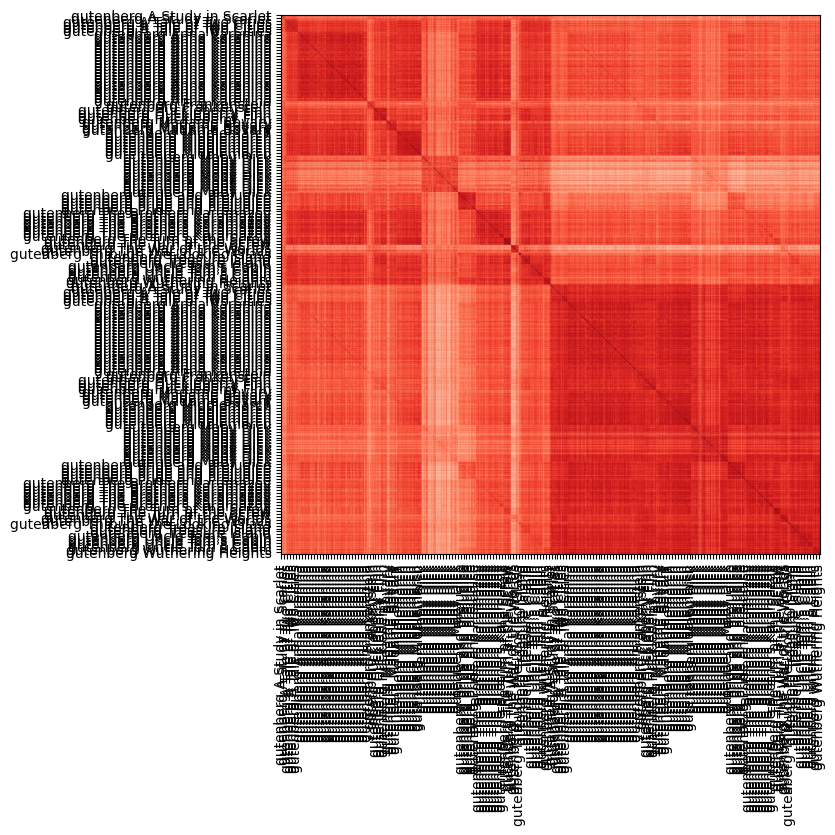

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))
plt.imshow(cs, cmap='Reds')
plt.xticks([i for i in range(0, len(prompts), 10)], novel[::10], rotation=90)
plt.yticks([i for i in range(0, len(prompts), 10)], novel[::10], rotation=0)
plt.show()

## t-sne

In [14]:
set(novel)

{np.str_('gutenberg A Study in Scarlet'),
 np.str_('gutenberg A Tale of Two Cities'),
 np.str_('gutenberg Anna Karenina'),
 np.str_('gutenberg Frankenstein'),
 np.str_('gutenberg Huckleberry Finn'),
 np.str_('gutenberg Madame Bovary'),
 np.str_('gutenberg Middlemarch'),
 np.str_('gutenberg Moby Dick'),
 np.str_('gutenberg Pride and Prejudice'),
 np.str_('gutenberg The Brothers Karamazov'),
 np.str_('gutenberg The Turn of the Screw'),
 np.str_('gutenberg The War of the Worlds'),
 np.str_('gutenberg Through the Looking Glass'),
 np.str_('gutenberg Treasure Island'),
 np.str_('gutenberg Uncle Tom’s Cabin'),
 np.str_('gutenberg Wuthering Heights')}

In [15]:
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = True

rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.linewidth'] = 2
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 35
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = False
rcParams['axes.spines.left'] = False

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 25
rcParams['xtick.labelsize'] = 25
rcParams['ytick.labelsize'] = 25
rcParams['figure.figsize'] = (4, 3)

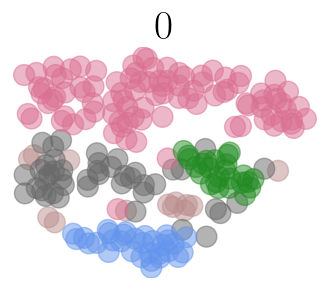

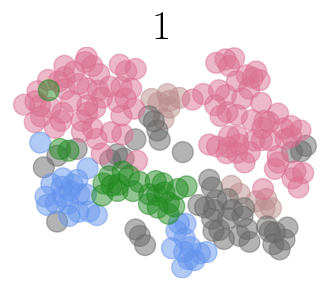

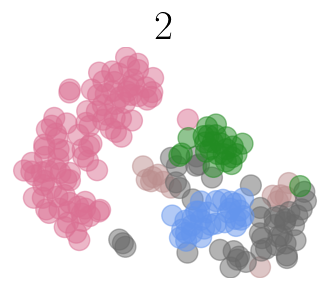

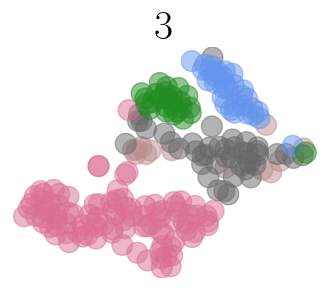

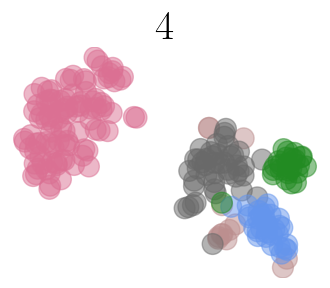

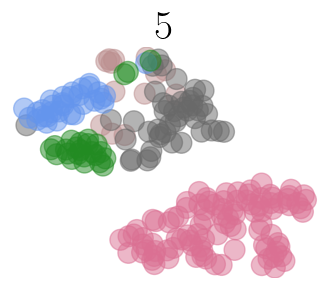

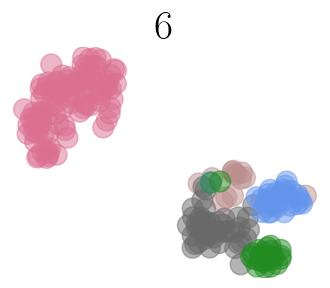

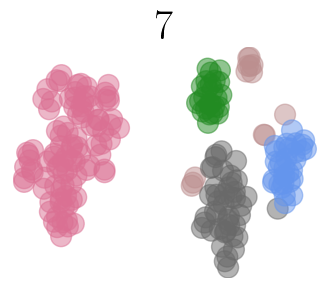

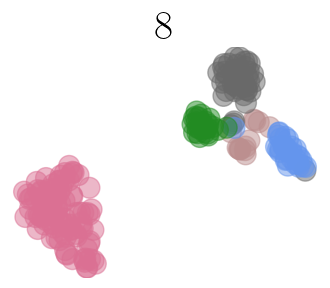

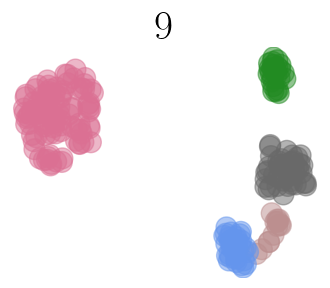

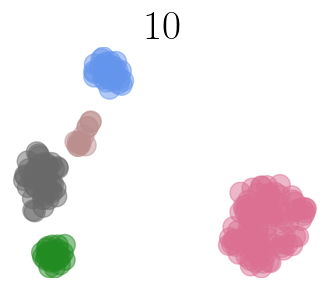

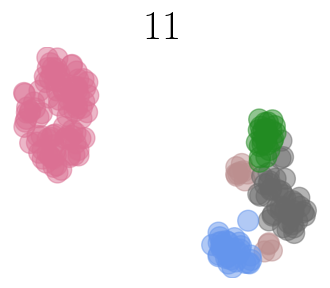

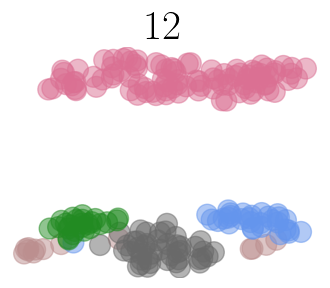

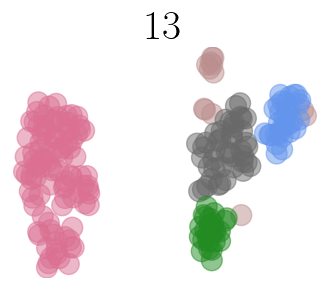

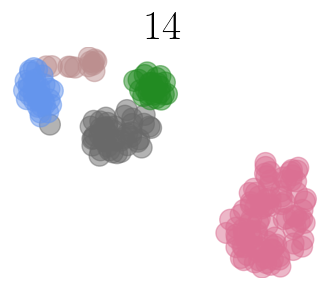

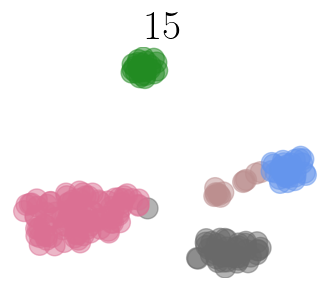

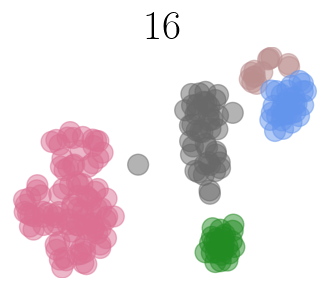

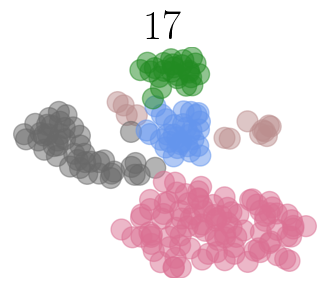

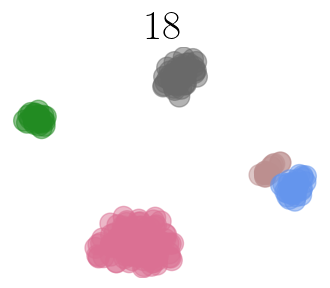

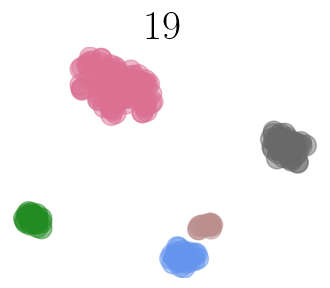

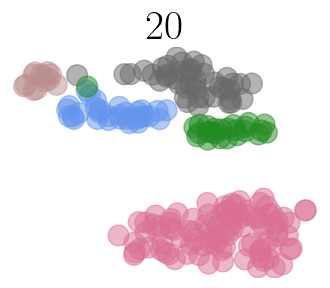

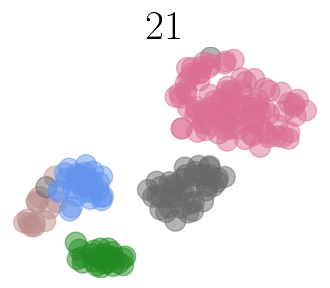

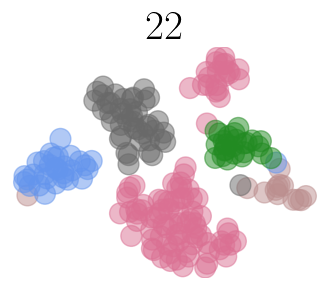

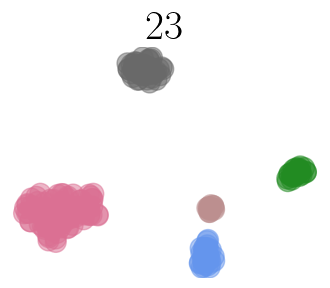

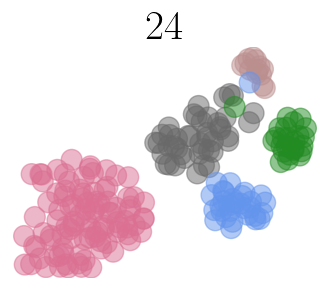

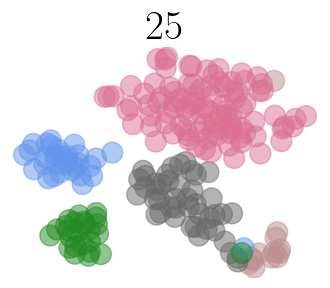

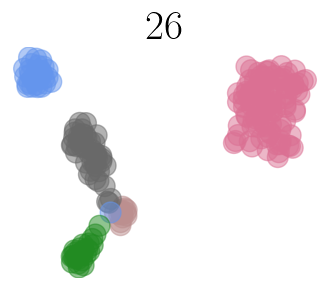

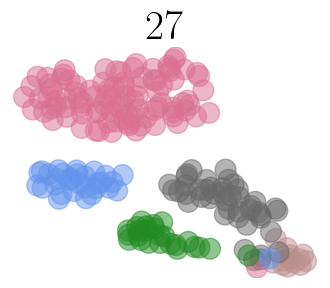

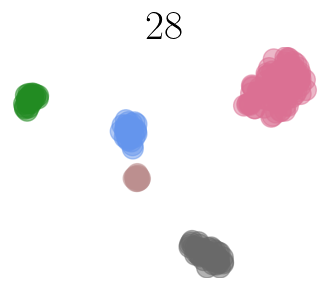

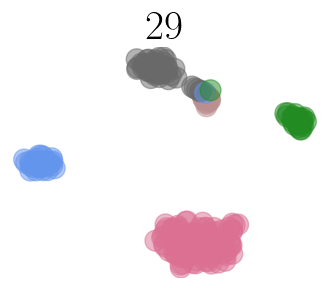

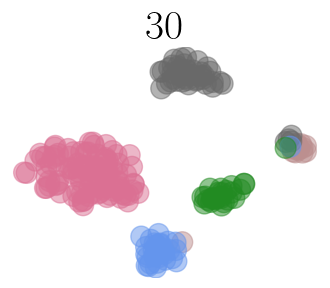

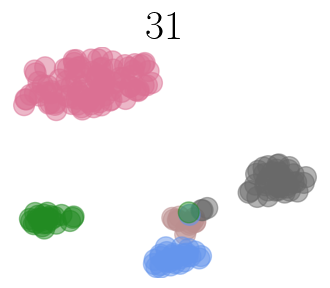

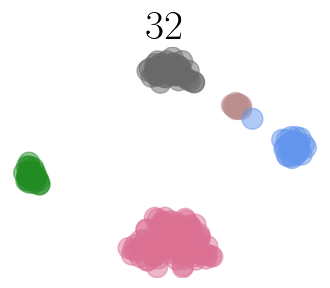

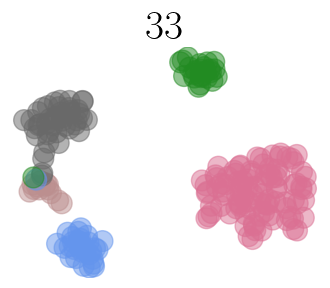

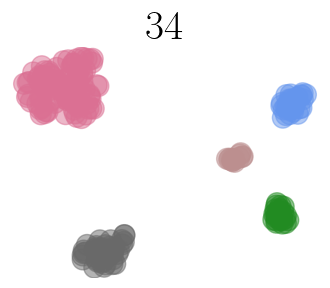

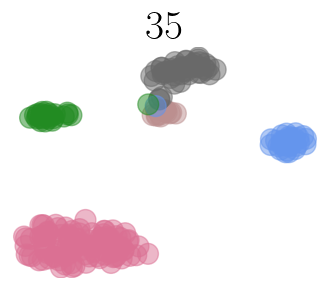

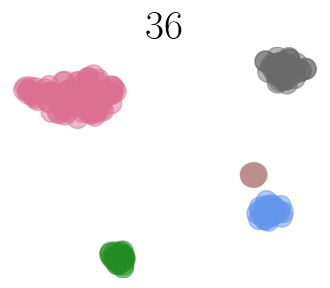

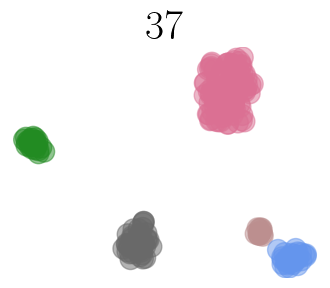

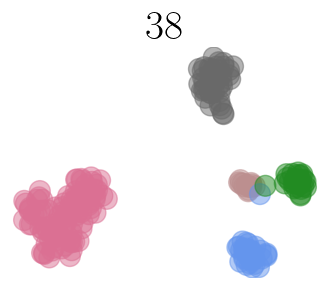

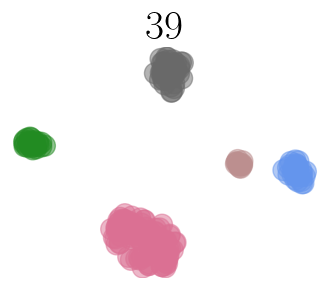

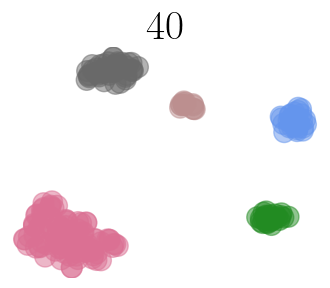

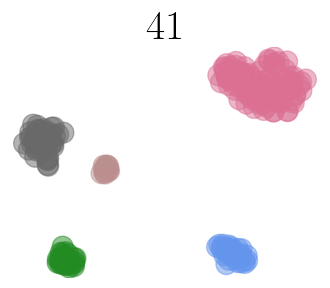

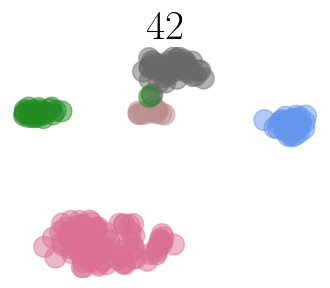

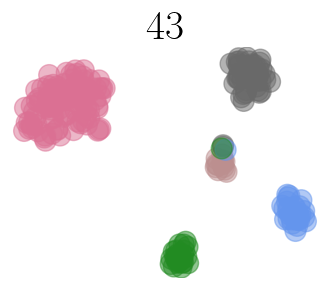

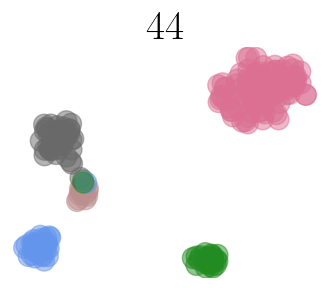

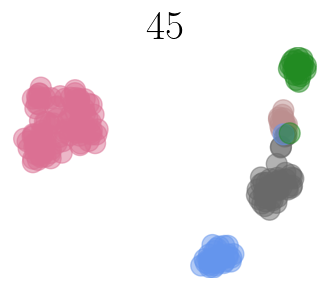

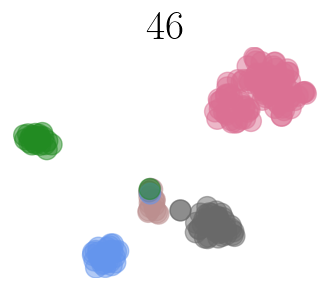

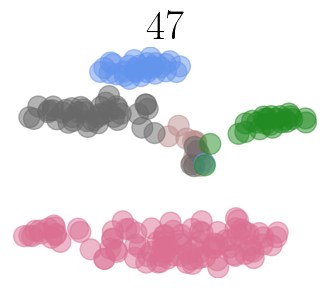

In [16]:
colors = []
for i in range(len(all_prompts_prototypes)):
    if (chosen_rejected[i] == 'rejected'):
        continue
    if (novel[i] == 'gutenberg A Study in Scarlet'):
        colors.append('rosybrown')
    if (novel[i] == 'gutenberg A Tale of Two Cities'):
        colors.append('dimgray')
    if (novel[i] == 'gutenberg Wuthering Heights'):
        colors.append('forestgreen')
    if (novel[i] == 'gutenberg Treasure Island'):
        colors.append('cornflowerblue')
    if (novel[i] == 'gutenberg The Brothers Karamazov'):
        colors.append('palevioletred')


for target_layer in target_layers:

    cur_concepts = []
    for i in range(len(prompts)):
        if (novel[i] in ['gutenberg A Study in Scarlet', 'gutenberg A Tale of Two Cities', 'gutenberg Wuthering Heights', 'gutenberg Treasure Island', 'gutenberg The Brothers Karamazov'] and chosen_rejected[i] == 'chosen'):
            cur_concepts.append(all_prompts_prototypes[i][target_layer])
    cur_concepts = torch.stack(cur_concepts, dim=0).squeeze()

    cur_concepts_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=20, random_state=0).fit_transform(cur_concepts.detach().cpu().float().numpy())

    plt.scatter(cur_concepts_emb[:, 0], cur_concepts_emb[:, 1], c=colors, alpha=0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(target_layer)
    plt.show()

In [15]:
cur_prototypes = []
for i in range(len(prompts)):
    cur_prototypes.append(all_prompts_prototypes[i][target_layer])
cur_prototypes = torch.stack(cur_prototypes, dim=0).squeeze()

In [16]:
cur_prototypes.shape

torch.Size([1836, 4096])

In [45]:
cur_prototypes_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=20, random_state=0).fit_transform(cur_prototypes.detach().cpu().numpy())

In [35]:
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = True

rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.linewidth'] = 2
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 35
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = False
rcParams['axes.spines.left'] = False

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 10
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['figure.figsize'] = (30, 10)

In [27]:
novel_values = list(set(novel))
novel_colors = ['#%06X' % randint(0, 0xFFFFFF) for _ in range(len(novel_values))]

novel_values, novel_colors

([np.str_('gutenberg Middlemarch'),
  np.str_('gutenberg Moby Dick'),
  np.str_('gutenberg Uncle Tom’s Cabin'),
  np.str_('gutenberg Through the Looking Glass'),
  np.str_('gutenberg Anna Karenina'),
  np.str_('gutenberg A Tale of Two Cities'),
  np.str_('gutenberg Madame Bovary'),
  np.str_('gutenberg The War of the Worlds'),
  np.str_('gutenberg Frankenstein'),
  np.str_('gutenberg Wuthering Heights'),
  np.str_('gutenberg The Turn of the Screw'),
  np.str_('gutenberg Huckleberry Finn'),
  np.str_('gutenberg Treasure Island'),
  np.str_('gutenberg Pride and Prejudice'),
  np.str_('gutenberg The Brothers Karamazov'),
  np.str_('gutenberg A Study in Scarlet')],
 ['#87BAFD',
  '#C3D361',
  '#09B74C',
  '#7FC7FA',
  '#DEE3EE',
  '#0A01BC',
  '#E6E785',
  '#5358FD',
  '#D33165',
  '#CB64FF',
  '#A644F6',
  '#FC104C',
  '#28D84D',
  '#445CCD',
  '#31A25E',
  '#E4E65A'])

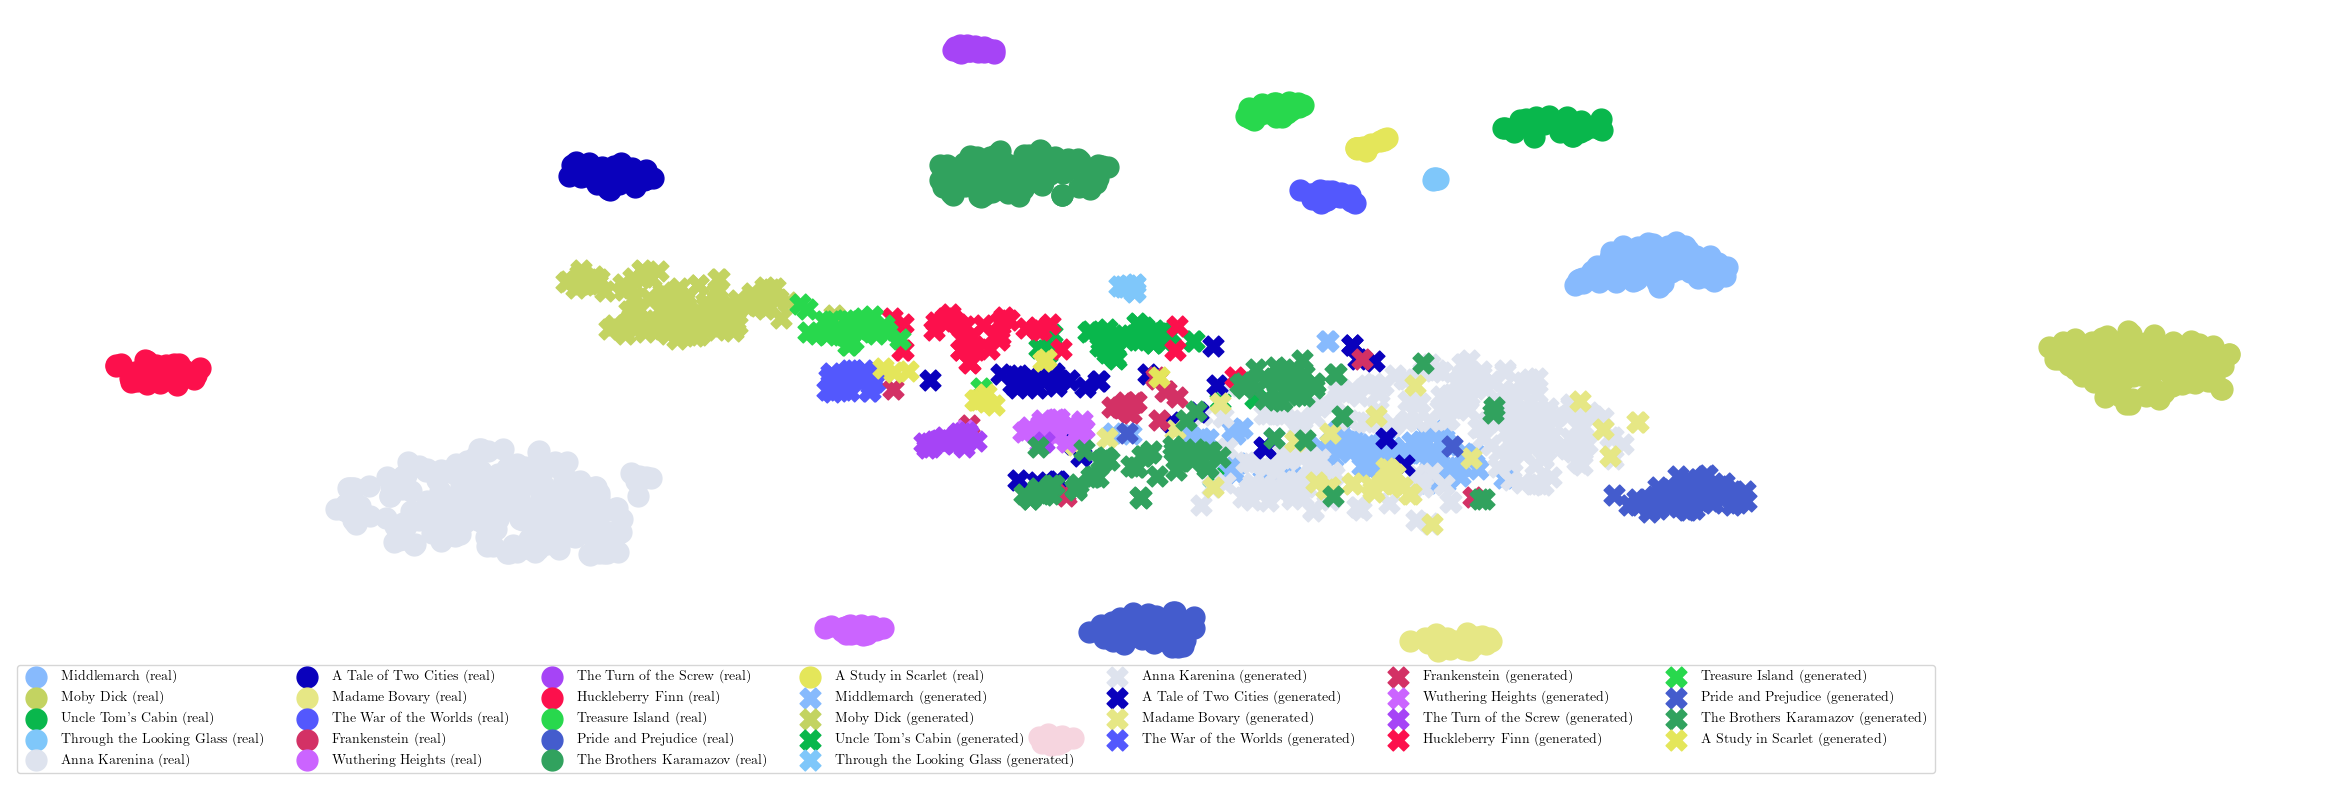

In [46]:


for t in ['chosen', 'rejected']:
    for i in range(len(novel_values)):

        plt.scatter(cur_prototypes_emb[(novel == novel_values[i]) & (chosen_rejected == t)][:, 0], 
                    cur_prototypes_emb[(novel == novel_values[i]) & (chosen_rejected == t)][:, 1], 
                    c=novel_colors[i],
                    marker='o' if t=='chosen' else 'X', 
                    label='%s (%s)' %(novel_values[i][9:], 'real' if t=='chosen' else 'generated'))
plt.xticks([])
plt.yticks([])
plt.legend(ncols=7)
plt.show()

# Classify real vs synthetic

In [5]:
df = pd.read_csv('data/DAIGT/train_drcat_04.csv')

In [6]:
df.head()

,essay_id,text,label,source,prompt,fold
0,E897534557AF,"In recent years, technology has had a profoun...",1,mistral7binstruct_v2,\nTask: Write an essay discussing the positive...,1
1,DFBA34FFE11D,Should students participate in an extracurricu...,0,persuade_corpus,NaN,2
2,af37ecf5,The electoral college is a symbol of mockery a...,0,train_essays,NaN,5
3,5EC2696BAD78,This is why I think the principle should allow...,0,persuade_corpus,NaN,8
4,llama_70b_v1843,I strongly believe that meditation and mindful...,1,llama_70b_v1,Some schools have implemented meditation and m...,0


In [7]:
train_folds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
test_folds = [9]

In [8]:
train_prompts = []
train_real = []
test_prompts = []
test_real = []


for i, row in tqdm(df.iterrows(), total=df.shape[0]):
    if (row['fold'] in train_folds):
        train_prompts.append(row['text'])
        train_real.append(row['label'])
    elif (row['fold'] in test_folds):
        test_prompts.append(row['text'])
        test_real.append(row['label'])


train_prompts = np.array(train_prompts)
train_real = np.array(train_real)

keep_idx = random.sample(list(range(len(train_prompts))), 5000)
train_prompts = train_prompts[keep_idx]
train_real = train_real[keep_idx]

len(train_prompts), len(test_prompts)

100%|██████████| 44206/44206 [00:00<00:00, 71167.83it/s]


(5000, 0)

In [9]:
def sort_two_arrays(arr1, arr2):
    """Sorts two arrays based on the order of the first array.

    Args:
    arr1: The array to sort by.
    arr2: The array to sort along with the first array.

    Returns:
    A tuple containing the sorted arr1 and arr2.
    """

    zipped_pairs = zip(arr1, arr2)
    sorted_pairs = sorted(zipped_pairs)

    sorted_arr1 = [x for x, _ in sorted_pairs]
    sorted_arr2 = [y for _, y in sorted_pairs]

    return sorted_arr1, sorted_arr2


train_real, train_prompts = sort_two_arrays(train_real, train_prompts)

## Train dataset

In [10]:
hidden_states = []

pbar = tqdm(enumerate(train_prompts), total=len(train_prompts))
for i, p in pbar:

    pbar.set_description('cur prompt length (chars): %d' %(len(p)))
    
    with torch.no_grad():
        inputs = tokenizer(p, return_tensors="pt").input_ids
        outputs = model.forward(inputs.to(device))
        
    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
        activations[k] =  torch.mean(activations[k], dim=-2)


    hidden_states.append(copy.deepcopy(activations))
    activations = {}

cur prompt length (chars): 2468: 100%|██████████| 5000/5000 [43:37<00:00,  1.91it/s]  


In [11]:
target_layers = [i for i in range(len(model.model.layers))]
train_all_prompts_prototypes = hidden_states

In [ ]:
target_layer = 17

In [ ]:
# dis = np.zeros((len(train_prompts), len(train_prompts)))
# cs = np.zeros((len(train_prompts), len(train_prompts)))

# cs_func = nn.CosineSimilarity(dim=-1)

# for i in range(len(train_prompts)):
#     for j in range(len(train_prompts)):
#         dis[i, j] = torch.linalg.norm(all_prompts_prototypes[i][target_layer] - all_prompts_prototypes[j][target_layer])
#         cs[i, j] = cs_func(all_prompts_prototypes[i][target_layer], all_prompts_prototypes[j][target_layer])

In [ ]:
# fig, ax = plt.subplots(figsize=(7, 7))
# plt.imshow(cs, cmap='Reds')
# plt.xticks([i for i in range(0, len(prompts), 10)], train_real[::10], rotation=90)
# plt.yticks([i for i in range(0, len(prompts), 10)], train_real[::10], rotation=0)
# plt.show()

## Test dataset

In [ ]:
# hidden_states = []

# pbar = tqdm(enumerate(test_prompts), total=len(test_prompts))
# for i, p in pbar:

#     pbar.set_description('cur prompt length (chars): %d' %(len(p)))
    
#     with torch.no_grad():
#         inputs = tokenizer(p, return_tensors="pt").input_ids
#         outputs = model.forward(inputs.to(device))
        
#     for k in activations.keys():
#         activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
#         activations[k] =  torch.mean(activations[k], dim=-2)


#     hidden_states.append(copy.deepcopy(activations))
#     activations = {}

In [ ]:
# test_all_prompts_prototypes = hidden_states

## knn

In [ ]:
target_layer = 17

In [ ]:
for target_layer in target_layers:

    X_train = np.array([p[target_layer] for p in train_all_prompts_prototypes]).squeeze()
    y_train = np.array(train_real)
    # X_test = np.array([p[target_layer] for p in test_all_prompts_prototypes]).squeeze()
    # y_test = np.array(test_real)

    neigh = KNeighborsClassifier(n_neighbors=11, metric='cosine', n_jobs=10)
    neigh.fit(X_train, y_train)

    os.makedirs('models/real_synth', exist_ok=True)
    with open('models/real_synth/knn_%d.pkl' %(target_layer), 'wb') as f:
        pickle.dump(neigh, f)

KNeighborsClassifier(metric='cosine', n_jobs=10, n_neighbors=11)

In [ ]:
# neigh.score(X_test, y_test)

In [ ]:
# probs = neigh.predict_proba(X_test)

In [ ]:
# probs[:10, :]

In [ ]:
# y_test